Hello here's my text.

In [93]:
# SETUP libraries and file paths
from pathlib import Path
from pytact.data_reader import data_reader
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import scipy

DATASET_PATH = Path("/Users/huubdejong/Documents/Education/UBC/M2PI_2025/Project/TacticianDataTemp/TacticianDataTemp/TacticianDataTemp/v15-stdlib-coq8.11/dataset").resolve()


In [94]:
# Main variables

tacticCounts = {'Unknown':{'count':0,'text':'Unknown','exact':False}}
conditionalCounts = {'Unknown':{}}
prooflessCounter = 0
definitionsCounter = 0
tacticsLookup = {'Done':['Done'], 'Unknown':['Unknown']} # TODO: fix to include Unknowns/unstable tactics
totals = pd.DataFrame()
twoStepBackConditionals = {}
twoStepForwardConditionals = {}
tacticCountsPerFile = {}

Here's some more text about the above and below.

In [ ]:
# All update methods
def updateTacticCounts(step):
        if step.tactic == None:
            #print("Bad tactic! " + str(step)) # check what happens here? From the docs: Sometimes a tactic cannot or should not be recorded. In those cases, it is marked as 'unknown'. This currently happens with tactics that are run as a result of the Proof with tac construct and it happens for tactics that are known to be unsafe like change_no_check, fix, cofix and more.
            tacticCounts['Unknown']['count'] += 1
        elif step.tactic.ident in tacticCounts:
            tacticCounts[step.tactic.ident]['count'] += 1
        else:
            tacticCounts.update({step.tactic.ident:{'count':1,'text':step.tactic.base_text, 'exact':step.tactic.exact}})
    

def updateConditionalCounts(tactic1, tactic2):
    if tactic1 not in conditionalCounts:
        conditionalCounts.update({tactic1: {tactic2: 1}})
    elif tactic2 not in conditionalCounts[tactic1]:
        conditionalCounts[tactic1].update({tactic2 : 1})
    else:
        conditionalCounts[tactic1][tactic2] += 1
    

def updateLookup(step):
    if step.tactic != None:
        if step.tactic.ident in tacticsLookup:
            if step.tactic.base_text not in tacticsLookup[step.tactic.ident]:
                tacticsLookup[step.tactic.ident].append(step.tactic.base_text)
        else:
            tacticsLookup.update({step.tactic.ident: [step.tactic.base_text]})
    

# For determining P(T_3 = step3 | T_2 = step2 , T_1 = step1) 
def updateTwoStepBackwardConditionalCounts(tactic1, tactic2, tactic3):
    if (tactic1,tactic2) not in twoStepBackConditionals:
        twoStepBackConditionals.update({(tactic1, tactic2): {tactic3 : 1}})
    elif tactic3 not in twoStepBackConditionals[(tactic1,tactic2)]:
        twoStepBackConditionals[(tactic1,tactic2)].update({tactic3 : 1})
    else:
        twoStepBackConditionals[(tactic1,tactic2)][tactic3] += 1


# For determining P(T_3 = step3, T_2 = step2 | T_1 = step1)
def updateTwoStepForwardConditionalCounts(tactic1, tactic2, tactic3):
    if tactic1 not in twoStepForwardConditionals:
        twoStepForwardConditionals.update({tactic1 : {(tactic2,tactic3) : 1}})
    elif (tactic2,tactic3) not in twoStepForwardConditionals[tactic1]:
        twoStepForwardConditionals[tactic1].update({(tactic2,tactic3) : 1})
    else: 
        twoStepForwardConditionals[tactic1][(tactic2,tactic3)] += 1


def updateCountsPerFile(filepath, tactic):
    if filepath not in tacticCountsPerFile:
        tacticCountsPerFile.update({filepath : { tactic : 1}})
    elif tactic not in tacticCountsPerFile[filepath]:
        tacticCountsPerFile[filepath].update({tactic : 1})
    else:
        tacticCountsPerFile[filepath][tactic] += 1

In [96]:

# helper to convert tactic into string
def classifyTactic(step):
    if step == None:
        return "Done"
    elif step.tactic == None:
        return "Unknown"
    else:
        return step.tactic.ident


In [ ]:
# parsing the data

rich = False

# this part parses the data and stores everything we might want to know about
with data_reader(DATASET_PATH) as data:
    for idx, (relative_path,dataset) in enumerate(data.items()):
        if rich: print("Parsing \"" + str(relative_path) + "\" for proofs...")
        for definition in dataset.definitions(spine_only=False): 
            #if definition.proof != None:
                #breakpoint()
            definitionsCounter += 1
            if definition.proof == None: #c might not have a proof! Check in what case this happens, I'm actually also not sure what this means... is c an axiom? 
                prooflessCounter += 1
                continue
            # this is where the updating and counting happens
            for i in range(len(definition.proof)): 
                t1 = classifyTactic(definition.proof[i])
                t2 = classifyTactic(definition.proof[i+1] if i < len(definition.proof) - 1 else None)
                t3 = classifyTactic(definition.proof[i+2] if i < len(definition.proof) - 2 else None)

                
                updateConditionalCounts(t1, t2) # update conditional distribution
                updateTwoStepBackwardConditionalCounts(t1,t2,t3)
                updateTwoStepForwardConditionalCounts(t1,t2,t3)
                
                # TODO: these ones are super inconsistent typing wise HAHAHA
                updateTacticCounts(definition.proof[i]) # update regular distribution
                updateLookup(definition.proof[i])
                updateCountsPerFile(relative_path, t1)
                
                
            
            # updating and counting done

# this part converts the data into a workable shape 
totals = pd.DataFrame(columns=['tacticHash','count','exact','text']) 
for k,v in tacticCounts.items():
    temp = pd.DataFrame.from_dict({'tacticHash': [k],
                                  'count':[v['count']],
                                  'exact':[v['exact']],
                                  'text':[v['text']],
                                  'nextDistribution':[conditionalCounts[k] if k in conditionalCounts else {}]})
    totals = pd.concat([totals,temp],ignore_index=True)  
totals= totals.sort_values(by='count',ascending=False)





Parsing "coq-tactician-stdlib.8.11.dev/plugins/ssrmatching/ssrmatching.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Ring_theory.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Ncring.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Rings_Z.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Field.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Ring_base.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Algebra_syntax.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Cring.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Ncring_tac.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Field_theory.bin" for proofs...
Parsing "coq-tactician-stdlib.8.11.dev/plugins/setoid_ring/Ncring_initial.bin" for proofs...
Parsing "coq-tactician-stdl

In [99]:
# print basic information
n = 10
print(str(totals.loc[totals['count'] < n].shape[0]) + " out of " + str(totals.shape[0])  + " tactics were used fewer than " + str(n) + " times.")
print("Total number of proofless definitions: " + str(prooflessCounter) + " out of " + str(definitionsCounter)) # 29033 out of 72580 definitions don't have a proof field... that's a lot! Possibly literal definitions


1457 out of 2384 tactics were used fewer than 10 times.
Total number of proofless definitions: 35012 out of 82378


Let's compute what the entropy of this random variable is!

In [111]:
# TODO: replace all of this with scipy as below

print("H(Step1) = " + str(scipy.stats.entropy(pk=[p for p in totals['count']])))



H(Step1) = 3.8371602967392135


In [109]:
# computing conditional entropy H(Step2|Step1)
totalx = 0
out = 0
for _,row in totals.iterrows():
    totalx += row['count']
    out += row['count'] * scipy.stats.entropy(pk = [p for p in row['nextDistribution'].values()])
conditionalEntropy = out / float(totalx)
print(conditionalEntropy)

2.635844172794473


In [ ]:

# TODO: these shouldn't be the same?
totalDist = {}
total = 0
for x in totals['count']:
    total += x

for _, row in totals.iterrows():
    totaly = 0
    for _,v in row['nextDistribution'].items():
        totaly += v
    for k,v in row['nextDistribution'].items():
        if k in totalDist:
            totalDist[k] += (v / float(totaly)) * (row['count'] / float(total)) #P(Y=y) = sum_x P(Y=y| X=x) P(X=x)
        else:
            totalDist.update({k:(v / float(totaly))* (row['count'] / float(total))})    

secondStepEntropy = scipy.stats.entropy(pk=[p for p in totalDist.values()])
print("H(Step2) = " + str(secondStepEntropy))
print("I(Step1,Step2) = H(Step2) - H(Step2|Step1) = " + str(secondStepEntropy - conditionalEntropy))
# X is random tactic, Y is random tactic that follows X so H(Y|X) is \sum_x H(Y|X=x)
#print(totalDist)

# why does this give the same number?
totalDist = {}
for _, row in totals.iterrows():
    for k,v in row['nextDistribution'].items():
        if k in totalDist:
            totalDist[k] += v
        else:
            totalDist.update({k:v})
print(scipy.stats.entropy(pk=[p for p in totalDist.values()]))
print(totalDist['Done'])






512753


H(Step2) = 3.7755021791566366
I(Step1,Step2) = H(Step2) - H(Step2|Step1) = 1.1396580063621635
3.775502179156631
47365
2384 2036 2036
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
collided = False
for k,v in tacticsLookup.items():
    if len(v) > 1:
        collided = True
        print("The following tactics have hash " + str(k) + ":")
        print(v)
if not collided:
    print("No tactichash collisions detected.")

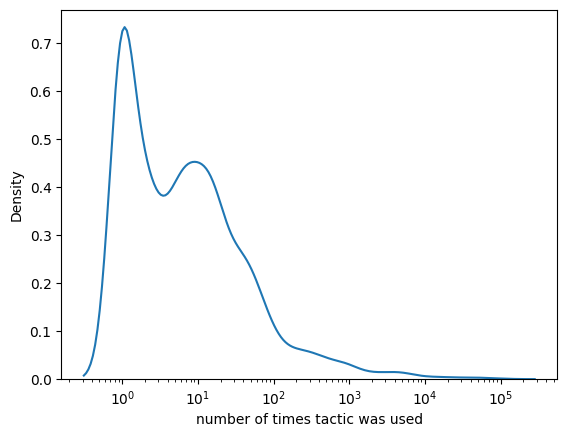

In [22]:
sns.kdeplot(totals['count'],log_scale=True)
plt.xlabel("number of times tactic was used")
plt.show()

Text(0.5, 1.0, 'Number of tactic uses per file')

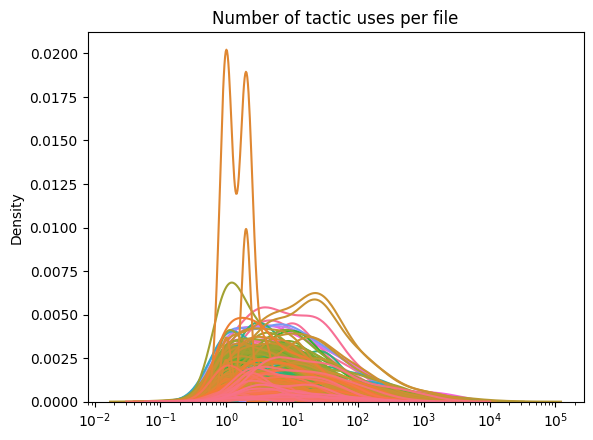

In [ ]:
# TODO: pick path through tree, see how distribution changes? check "Pillow" library to stitch pictures together. This looks like: 1) turn path into sequence of .bin file names, find their corresponding dists, stitch together

data = { k.name : {str(tact): count for tact, count in v.items() } for k,v in tacticCountsPerFile.items()}
sns.kdeplot(data, log_scale=True, legend=False, warn_singular=False)
plt.title("Number of tactic uses per file")

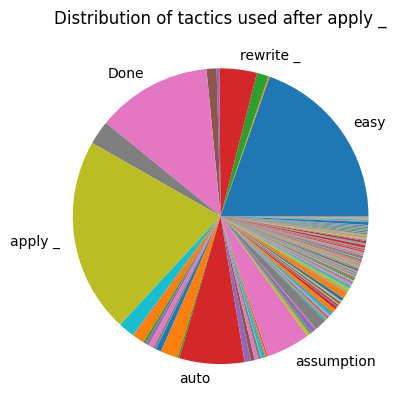

In [168]:
tacticHash = 3192827940261208899 # intros: 2091839244048452363 or destruct: 9120222886189897970 or easy: 3705308508539391475
# induction: 7871868389188524885, rewrite: 3535549731613791139 , rewrite <-: 4237068880675071532, exact: -8499735706083503724	, apply: 3192827940261208899, 
# there are also lots of variations such as: rewrite _ in __: 9050438711924037266, rewrite <- in : 3579137785924911933, coinduction ltac: -8126988681580081290, many apply


data = conditionalCounts[tacticHash]
totaly = 0
for v in data.values():
  totaly += v
plt.pie(data.values(), labels=[tacticsLookup[k][0] if (v/float(totaly) > 0.03) else '' for k,v in data.items()])
#plt.pie(data.values())
plt.title("Distribution of tactics used after " + str(tacticsLookup[tacticHash][0]))
plt.savefig(str(tacticHash) + "_OneStep.png")
plt.show()

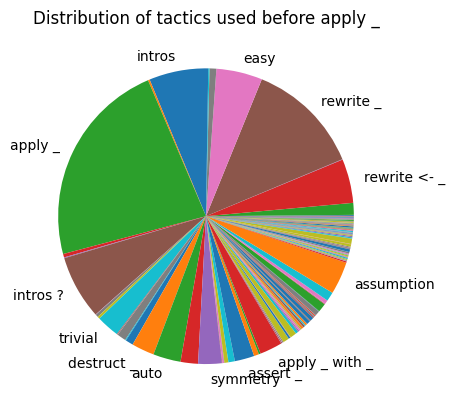

In [169]:
data = {tacticsLookup[tact][0]: d[tacticHash] if tacticHash in d else 0 for tact, d in conditionalCounts.items()}
total = 0
for v in data.values():
  total+= v
plt.pie(data.values(),labels=[key if data[key]/float(total) > 0.02 else '' for key in data.keys()])
plt.title("Distribution of tactics used before " + str(tacticsLookup[tacticHash][0]))
plt.show()


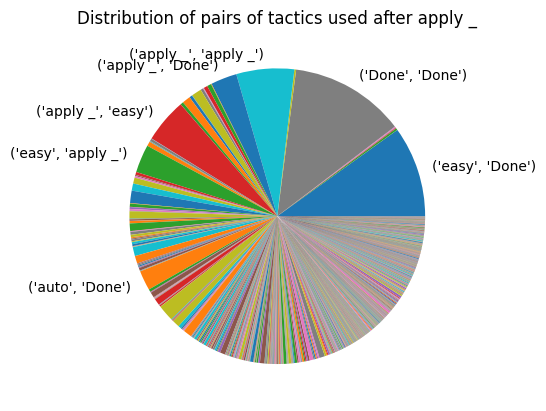

In [157]:
data = twoStepForwardConditionals[tacticHash]
totaly = 0
for v in data.values():
  totaly += v
plt.pie(data.values(), labels=[(tacticsLookup[k[0]][0], tacticsLookup[k[1]][0]) if (v/float(totaly) > 0.02) else '' for k,v  in data.items()])
#plt.pie(data.values())
plt.title("Distribution of pairs of tactics used after " + str(tacticsLookup[tacticHash][0]))
plt.savefig(str(tacticHash) + "_TwoStep.png")
plt.show()

In [144]:
L1 = [t for t in totals['text']]
L1.sort()
totals.loc[totals['text'] == "coinduction ltac:(__argument_marker__)"]

,tacticHash,count,exact,text,nextDistribution
1825,-8126988681580081290,7,True,coinduction ltac:(__argument_marker__),"{-4977013202206551511: 1, -2215863495585156535..."


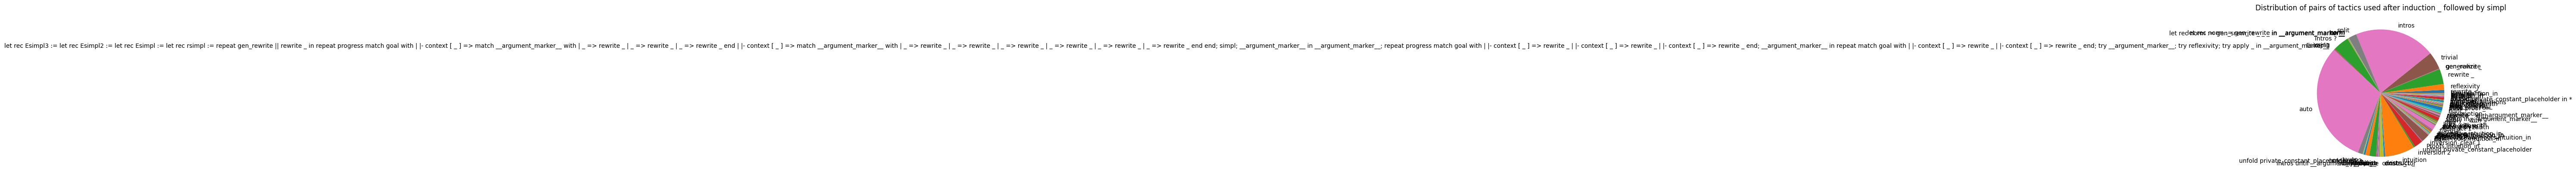

In [ ]:
data = twoStepBackConditionals[(7871868389188524885, 3100548622130897406)]
plt.pie(data.values(), labels=[tacticsLookup[k][0] for k in data.keys()])
#plt.pie(data.values())
plt.title("Distribution of tactics used after " + str(tacticsLookup[7871868389188524885][0]) + " followed by " + str(tacticsLookup[3100548622130897406][0]))
plt.show()


In [90]:
# TODO: proof state trees, wasserstein distance between different trees? 